# Suite 2 — Micro-Level Spatial Downscaling Efficacy

**Goal:** did the CF + per-model calibration downscaling fix the catastrophic municipal bias (large negative for wind, positive for solar)?

Sources: `results/kwusterhausen/kw_multi_model_validation.parquet` (per-hour Königs Wusterhausen actuals + already-calibrated per-model predictions), `results/kwusterhausen/kw_validation_metrics.csv`, and `results/macro_cv_metrics.csv`.

In [1]:
import os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Anchor to repo root so relative data/results paths work whether the notebook
# is launched from notebooks/ or the project root.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.titleweight": "bold", "axes.grid": True, "grid.alpha": 0.3,
})
FIG = "results/figures"
os.makedirs(FIG, exist_ok=True)

def save(fig, name):
    p = os.path.join(FIG, name)
    fig.savefig(p)
    print("saved ->", p)
    return p

# Consistent model palette across every suite.
MODEL_ORDER = ["persistence", "climatology", "lightgbm", "xgboost", "ebm", "bilstm", "tft"]
PAL = dict(zip(MODEL_ORDER, sns.color_palette("colorblind", len(MODEL_ORDER))))
BASELINES = {"persistence", "climatology"}


In [2]:
kw = pd.read_parquet("results/kwusterhausen/kw_multi_model_validation.parquet")
kw.index = pd.to_datetime(kw.index, utc=True)
kwm = pd.read_csv("results/kwusterhausen/kw_validation_metrics.csv")
ACT = {"wind": "windkraft", "solar": "photovoltaik"}
MODELS = {"wind": ["lightgbm","xgboost","ebm","bilstm","tft"],
          "solar": ["lightgbm","xgboost","ebm","bilstm","tft"]}
print(kw.shape); kw.head(2)

(851, 16)


,photovoltaik,windkraft,pred_lightgbm_wind,pred_lightgbm_wind_lower,pred_lightgbm_wind_upper,pred_xgboost_wind,pred_ebm_wind,pred_bilstm_wind,pred_lightgbm_solar,pred_lightgbm_solar_lower,pred_lightgbm_solar_upper,pred_xgboost_solar,pred_ebm_solar,pred_bilstm_solar,pred_tft_wind,pred_tft_solar
2026-05-28 13:00:00+00:00,2310.840468,238.119917,799.846243,620.153726,1027.690174,761.107706,845.251887,NaN,2631.078873,2307.998555,2848.949955,2642.504424,2491.993749,NaN,NaN,NaN
2026-05-28 14:00:00+00:00,2132.708920,447.309750,783.893666,660.579844,993.964746,774.633456,921.519070,NaN,2265.087256,2163.310318,2566.754301,2286.083161,2235.960363,NaN,NaN,NaN


## 2a — Municipal residual distributions (pred − actual)

A downscaler that works is centred on zero. The pre-rework failure was a large-magnitude offset.

saved -> results/figures/s2_residual_kde.png


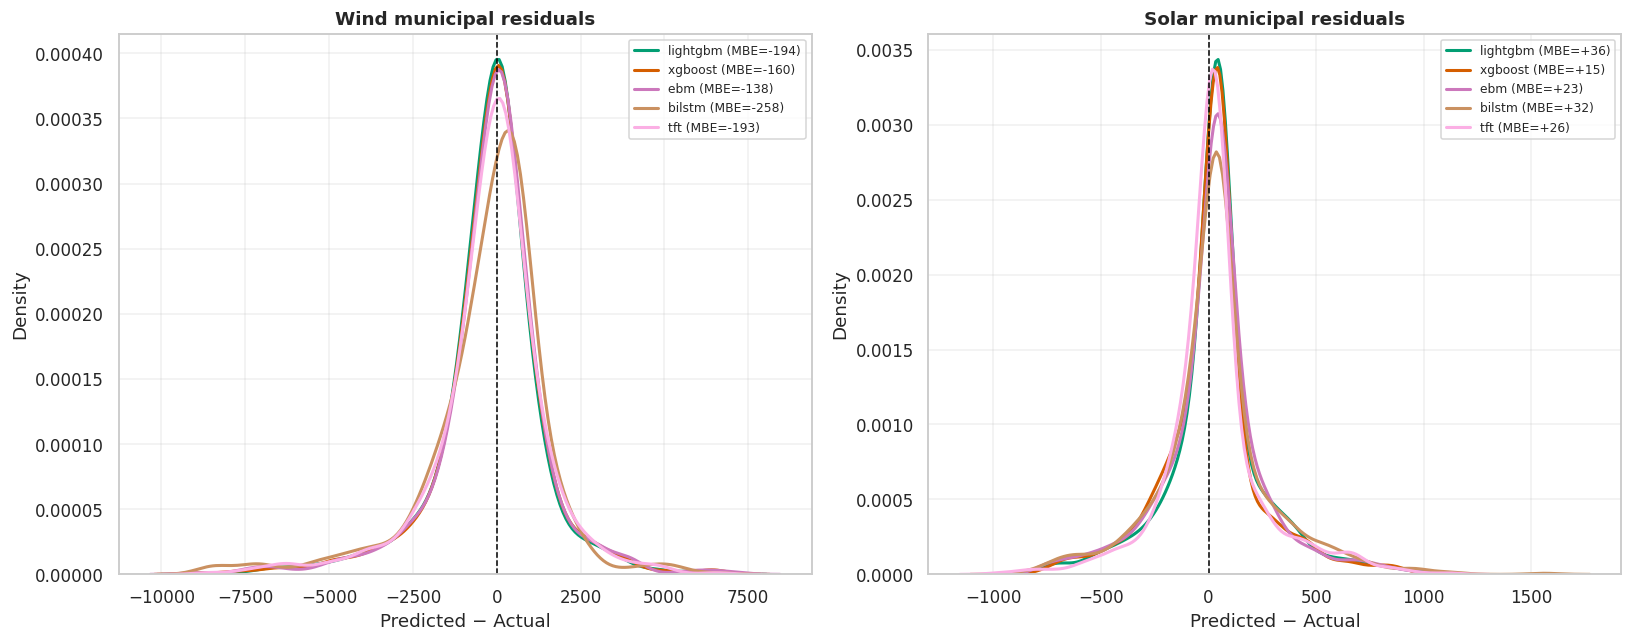

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, tech in zip(axes, ["wind","solar"]):
    act = kw[ACT[tech]]
    for model in MODELS[tech]:
        col = f"pred_{model}_{tech}"
        resid = (kw[col] - act).dropna()
        sns.kdeplot(resid, ax=ax, label=f"{model} (MBE={resid.mean():+.0f})",
                    color=PAL[model], lw=2)
    ax.axvline(0, color="black", ls="--", lw=1)
    ax.set_title(f"{tech.title()} municipal residuals"); ax.set_xlabel("Predicted − Actual")
    ax.legend(fontsize=8)
fig.tight_layout(); save(fig, "s2_residual_kde.png"); plt.show()

## 2b — Hour-of-day Mean Bias Error heatmaps

Which times of day (proxy for weather/irradiance regime) still break the downscaler.

saved -> results/figures/s2_mbe_hour_heatmap.png


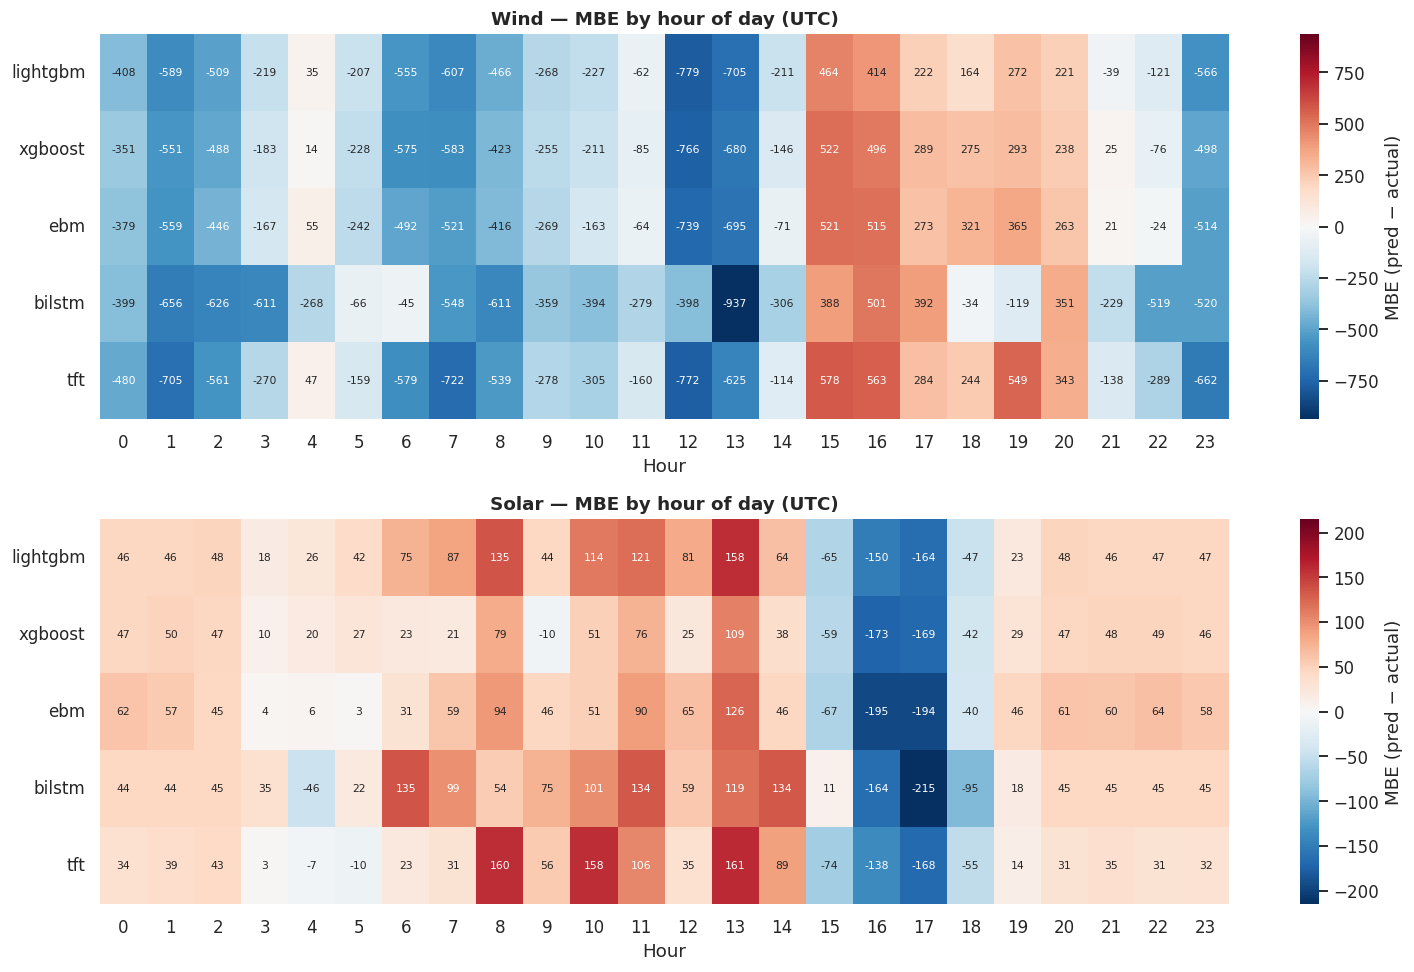

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
for ax, tech in zip(axes, ["wind","solar"]):
    act = kw[ACT[tech]]
    mat = {}
    for model in MODELS[tech]:
        resid = kw[f"pred_{model}_{tech}"] - act
        mat[model] = resid.groupby(resid.index.hour).mean()
    M = pd.DataFrame(mat).T.reindex(index=MODELS[tech])
    vmax = np.nanmax(np.abs(M.values))
    sns.heatmap(M, ax=ax, cmap="RdBu_r", center=0, vmin=-vmax, vmax=vmax,
                cbar_kws={"label": "MBE (pred − actual)"}, annot=True, fmt=".0f", annot_kws={"size":7})
    ax.set_title(f"{tech.title()} — MBE by hour of day (UTC)"); ax.set_xlabel("Hour"); ax.set_ylabel("")
fig.tight_layout(); save(fig, "s2_mbe_hour_heatmap.png"); plt.show()

## 2c — Scale gap: macro (state) vs micro (municipal) nMAE

saved -> results/figures/s2_macro_vs_micro_nmae.png


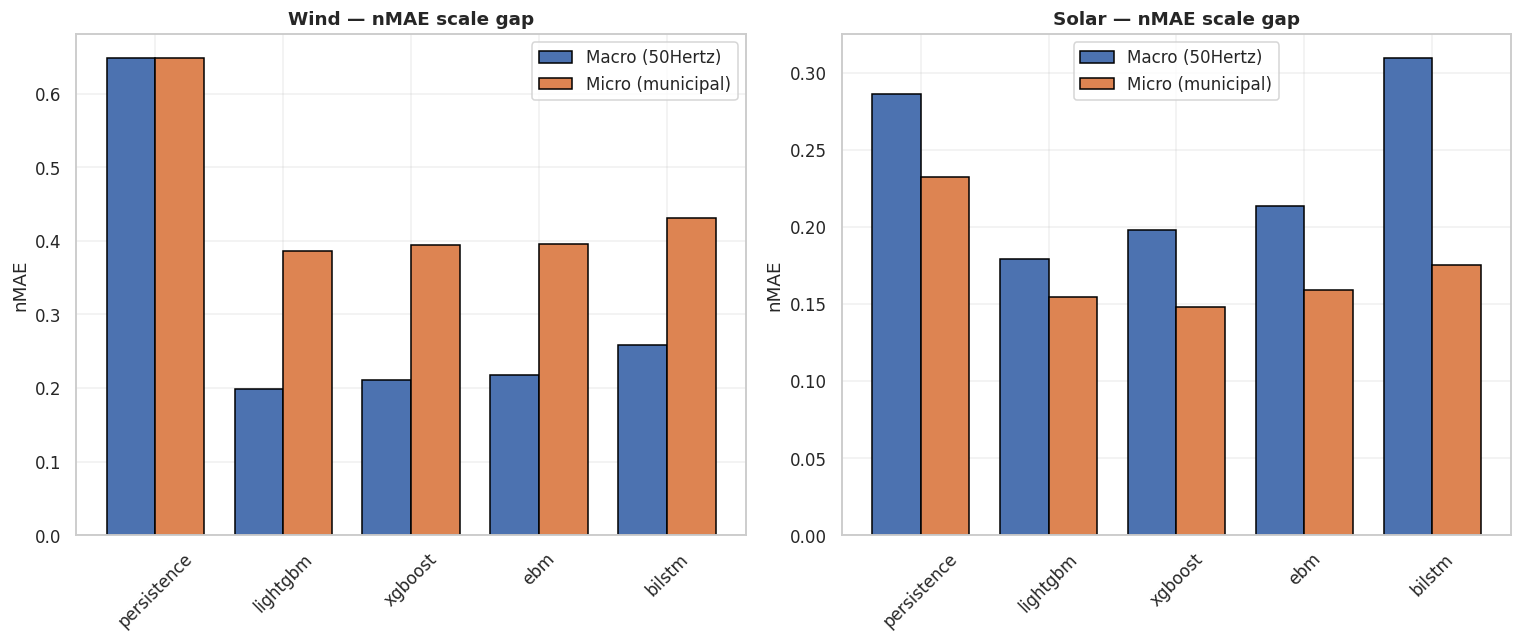

,technology,model,macro_nmae,micro_nmae
3,solar,persistence,0.286020,0.232015
2,solar,lightgbm,0.179330,0.154424
4,solar,xgboost,0.198087,0.148177
1,solar,ebm,0.213673,0.158938
0,solar,bilstm,0.309704,0.175001
8,wind,persistence,0.648866,0.649050
7,wind,lightgbm,0.198849,0.386550
9,wind,xgboost,0.211046,0.393955
6,wind,ebm,0.218054,0.396385
5,wind,bilstm,0.258127,0.431472


In [5]:
# Macro nMAE at MW scale, averaged over folds; micro nMAE straight from the
# municipal validation metrics.
macro = pd.read_csv("results/macro_cv_metrics.csv")
macro_mw = macro[macro.scale == "mw"].groupby(["technology","model"])["nmae"].mean().reset_index()
macro_mw = macro_mw.rename(columns={"nmae":"macro_nmae"})
micro = kwm.rename(columns={"nmae":"micro_nmae"})[["technology","model","micro_nmae"]]
comp = macro_mw.merge(micro, on=["technology","model"], how="inner")
comp["model"] = pd.Categorical(comp["model"], MODEL_ORDER, ordered=True)
comp = comp.sort_values(["technology","model"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, tech in zip(axes, ["wind","solar"]):
    sub = comp[comp.technology == tech]
    x = np.arange(len(sub)); w = 0.38
    ax.bar(x - w/2, sub["macro_nmae"], w, label="Macro (50Hertz)", color="#4c72b0", edgecolor="black")
    ax.bar(x + w/2, sub["micro_nmae"], w, label="Micro (municipal)", color="#dd8452", edgecolor="black")
    ax.set_xticks(x); ax.set_xticklabels(sub["model"].astype(str), rotation=45)
    ax.set_title(f"{tech.title()} — nMAE scale gap"); ax.set_ylabel("nMAE"); ax.legend()
fig.tight_layout(); save(fig, "s2_macro_vs_micro_nmae.png"); plt.show(); comp